# Gaussian Mixture Models

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ujjwal091/ai-ml-course/blob/main/modules/02-unsupervised-learning/gaussian-mixture-models/notes.ipynb)

*Teaching a clustering algorithm to say "maybe."*

**The brief:** you're the analyst on the Growth/Marketing team at Veloura, a mid-size online fashion & lifestyle
retailer. ~40,000 customers, 12 behavioral features. Marketing wants to stop blasting the same 20%-off code to
everyone and start personalizing campaigns. Last time, you reached for [Hierarchical Clustering](../hierarchical-clustering/notes.ipynb)
— the tool you already knew. This is where it breaks, and what you reach for instead.


## 1. Where Hierarchical Clustering breaks at Veloura's scale

Last session's tool, [Hierarchical Clustering](../hierarchical-clustering/notes.ipynb), doesn't need a pre-picked
number of clusters, and it gives a dendrogram to explore structure at different granularities. That flexibility
looked great on a small sample. Veloura has ~40,000 customers. Two problems show up fast.

**Problem 1 — scale.** Hierarchical clustering has to track distances between every pair of clusters as it
merges. On 40,000 customers, that's on the order of ~800 million pairwise distances just to get started. The
fit time grows very fast as the customer count grows:


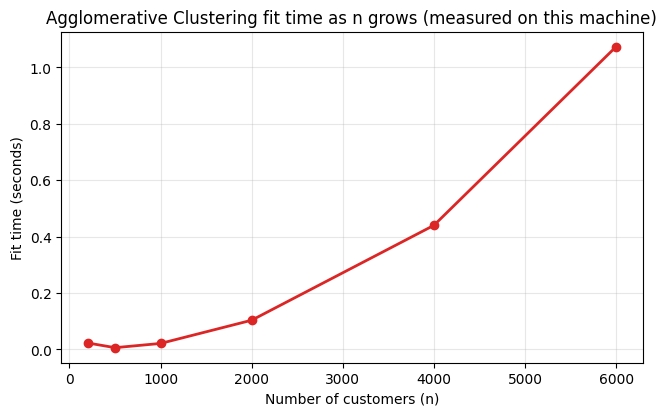

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs

sizes_n = [200, 500, 1000, 2000, 4000, 6000]
fit_times = []
for n in sizes_n:
    X_timing, _ = make_blobs(n_samples=n, centers=4, random_state=1)
    t0 = time.perf_counter()
    AgglomerativeClustering(n_clusters=4).fit(X_timing)
    fit_times.append(time.perf_counter() - t0)

plt.figure(figsize=(7.5, 4.3))
plt.plot(sizes_n, fit_times, marker="o", color="#DC2626", linewidth=2)
plt.xlabel("Number of customers (n)")
plt.ylabel("Fit time (seconds)")
plt.title("Agglomerative Clustering fit time as n grows (measured on this machine)")
plt.grid(alpha=0.3)
plt.show()

At Veloura's real scale (~40,000 customers) this curve keeps climbing — both the compute time and the memory
needed to hold the full distance matrix become a real problem, well before you get anywhere near 40,000 rows.

**Problem 2 — rigid, hard-boundary assignment.** Imagine a customer who spends a lot *and* always waits for a
discount code. They sit right at the boundary between two segments. Hierarchical clustering still has to drop
them fully into exactly one branch — there's no way to say "this customer is kind of both."


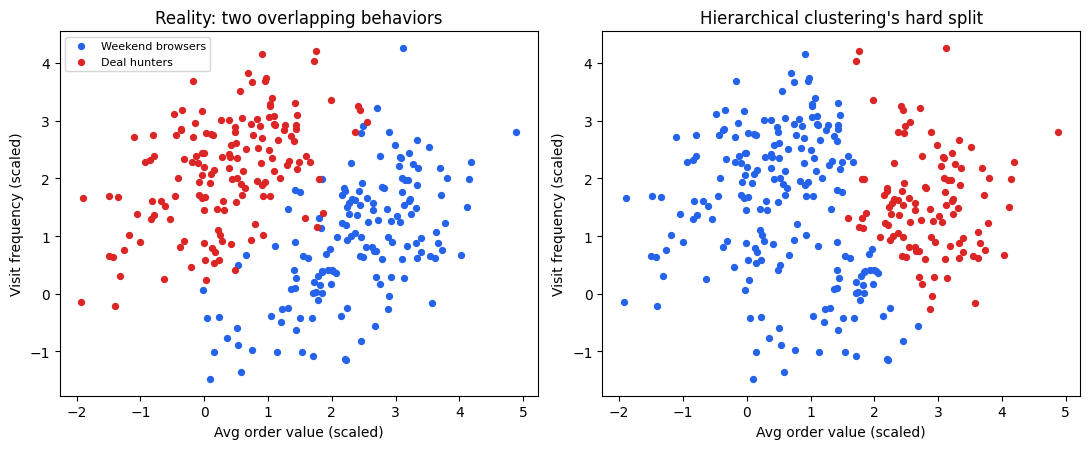

In [2]:
rng = np.random.RandomState(4)
cov_overlap = np.array([[1.0, 0.55], [0.55, 1.0]])
weekend_browsers = rng.multivariate_normal([2.5, 1.0], cov_overlap, 150)
deal_hunters = rng.multivariate_normal([0.5, 2.2], cov_overlap, 150)
X_overlap = np.vstack([weekend_browsers, deal_hunters])
true_overlap_labels = np.array([0] * 150 + [1] * 150)

hc_overlap_labels = AgglomerativeClustering(n_clusters=2, linkage="ward").fit_predict(X_overlap)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
axes[0].scatter(*weekend_browsers.T, s=18, color="#2563EB", label="Weekend browsers")
axes[0].scatter(*deal_hunters.T, s=18, color="#DC2626", label="Deal hunters")
axes[0].set_title("Reality: two overlapping behaviors")
axes[0].legend(fontsize=8)

axes[1].scatter(X_overlap[hc_overlap_labels == 0, 0], X_overlap[hc_overlap_labels == 0, 1], s=18, color="#2563EB")
axes[1].scatter(X_overlap[hc_overlap_labels == 1, 0], X_overlap[hc_overlap_labels == 1, 1], s=18, color="#DC2626")
axes[1].set_title("Hierarchical clustering's hard split")

for ax in axes:
    ax.set_xlabel("Avg order value (scaled)"); ax.set_ylabel("Visit frequency (scaled)")
plt.tight_layout()
plt.show()

"Weekend browsers" (moderate spend, come back often just to browse) and "deal hunters" (lower spend, high
frequency, but only when there's a discount) genuinely overlap in feature space. Hierarchical clustering draws a
hard line straight through the overlap zone — whichever side a customer lands on, the model gives no way to
express "this customer resembles both segments."

**The core idea:** *hard clustering* means every point gets assigned to exactly one cluster, no matter how
ambiguous its location is. Hierarchical clustering and K-Means are both hard clustering methods — the assignment
step gives a single, final label with no notion of "maybe." That rigidity, combined with the scale problem, is
exactly the gap the rest of this notebook closes.


**Quick check**

> A Veloura customer spends a lot and always waits for discount codes. Under a hard clustering method like
> Hierarchical Clustering or K-Means, how would this customer be treated?
>
> **Forced into exactly one cluster, even though they resemble both.** Not split proportionally, not flagged as
> noise, not ignored — hard clustering has no mechanism for "maybe."


## 2. The missing idea: soft clustering

Instead of forcing an ambiguous customer into one bucket, give every customer a **probability** of belonging to
each segment — e.g. "60% high spender, 40% deal hunter" instead of a single hard label. That's **soft
clustering**: every point gets a distribution over clusters instead of a single forced label.

So — how do we actually produce these probabilities in a principled way? That's where the Gaussian distribution
comes in.


## 3. Building block: Gaussian distributions — 1D

Why a Gaussian, specifically? Most natural, continuous behavioral metrics — like a customer's average order
value — cluster around some typical value and taper off symmetrically on either side. Most customers spend
"around normal," fewer spend way more or way less. That empirical shape is a bell curve: the **Gaussian (Normal)
distribution**.

$$
f(x \mid \mu, \sigma) = \frac{1}{\sigma \sqrt{2\pi}} \, e^{-\frac{(x - \mu)^2}{2\sigma^2}}
$$

- $\mu$ (mean) — where the peak sits
- $\sigma$ (standard deviation) — how spread out the curve is
- Key properties: mean = median = mode, and it's symmetric around the mean

**Likelihood of a point** is the *height of the curve* at that x-value — not a probability by itself, just how
"typical" that value is under this Gaussian.


In [3]:
def gaussian_1d(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

mu, sigma = 90, 25
aov_query = 130
likelihood_at_130 = gaussian_1d(aov_query, mu, sigma)
print(f"Gaussian(mu={mu}, sigma={sigma}) likelihood at AOV={aov_query}: {likelihood_at_130:.5f}")
print(f"Peak height (at x=mu): {gaussian_1d(mu, mu, sigma):.5f}")

Gaussian(mu=90, sigma=25) likelihood at AOV=130: 0.00444
Peak height (at x=mu): 0.01596


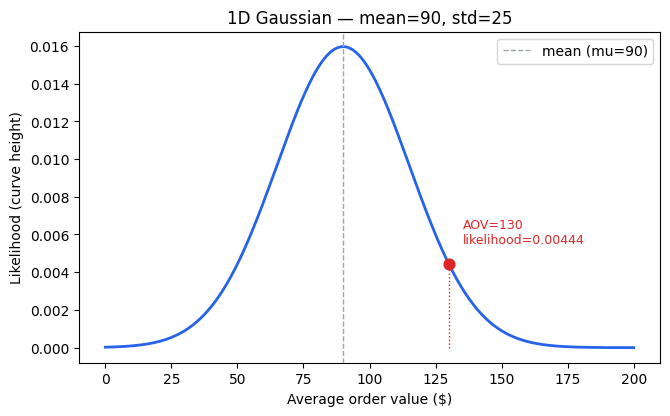

In [4]:
xs = np.linspace(0, 200, 400)
ys = gaussian_1d(xs, mu, sigma)

plt.figure(figsize=(7.5, 4.3))
plt.plot(xs, ys, color="#2563EB", linewidth=2)
plt.axvline(mu, color="#9CA3AF", linestyle="--", linewidth=1, label=f"mean (mu={mu})")
plt.scatter([aov_query], [likelihood_at_130], color="#DC2626", zorder=5, s=60)
plt.plot([aov_query, aov_query], [0, likelihood_at_130], color="#DC2626", linestyle=":", linewidth=1)
plt.annotate(f"AOV={aov_query}\nlikelihood={likelihood_at_130:.5f}", (aov_query, likelihood_at_130),
             textcoords="offset points", xytext=(10, 15), fontsize=9, color="#DC2626")
plt.xlabel("Average order value ($)"); plt.ylabel("Likelihood (curve height)")
plt.title(f"1D Gaussian — mean={mu}, std={sigma}")
plt.legend()
plt.show()

## 4. Building block: Gaussian distributions — 2D

Veloura customers aren't described by one number — spend, frequency, recency, and more, all at once. The
multivariate version of the Gaussian replaces the curve with a **surface** over a plane (say, average order
value × visit frequency): the peak is the most likely (AOV, frequency) combination, and probability density
falls off in any direction away from center.

With just a mean and variance per axis, you only get **axis-aligned** ellipses — that assumes the two features
are independent. In reality they're often correlated: deal hunters tend to have low spend *and* high frequency
together. That correlation is exactly what **covariance** captures — the extra parameter that lets the ellipse
rotate to match how two features actually move together.


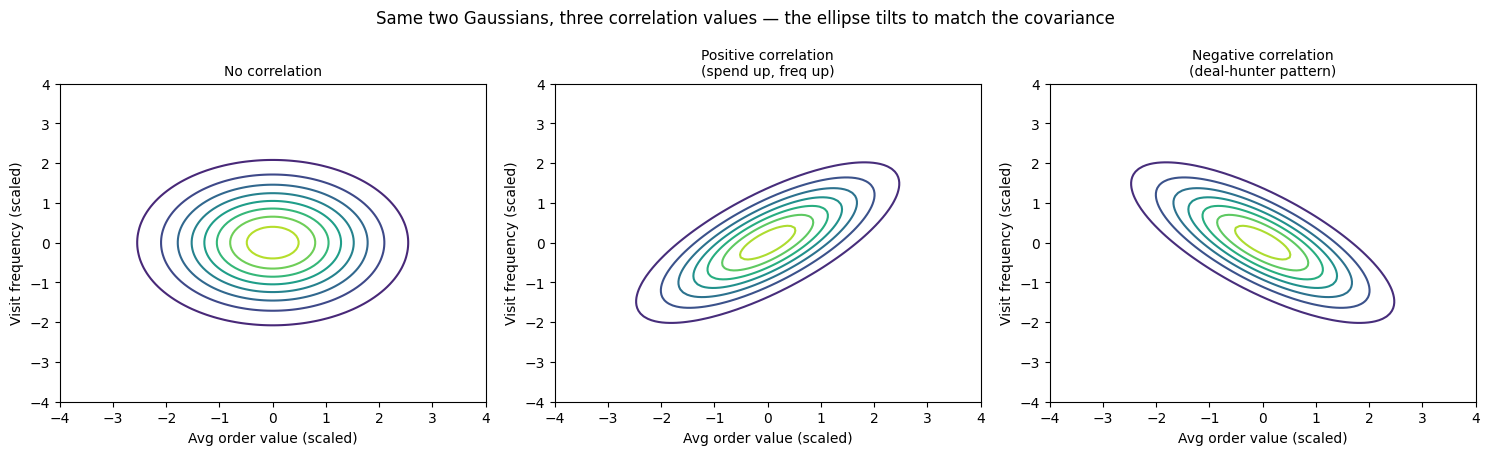

In [5]:
from scipy.stats import multivariate_normal

def corr_gaussian_grid(corr):
    cov = np.array([[1.5, corr * 1.2], [corr * 1.2, 1.0]])
    xg, yg = np.meshgrid(np.linspace(-4, 4, 120), np.linspace(-4, 4, 120))
    pos = np.dstack((xg, yg))
    zg = multivariate_normal([0, 0], cov).pdf(pos)
    return xg, yg, zg

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
titles = ["No correlation", "Positive correlation\n(spend up, freq up)", "Negative correlation\n(deal-hunter pattern)"]
for ax, corr, title in zip(axes, [0.0, 0.75, -0.75], titles):
    xg, yg, zg = corr_gaussian_grid(corr)
    ax.contour(xg, yg, zg, levels=8, cmap="viridis")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Avg order value (scaled)"); ax.set_ylabel("Visit frequency (scaled)")
plt.suptitle("Same two Gaussians, three correlation values — the ellipse tilts to match the covariance")
plt.tight_layout()
plt.show()

- **No correlation:** contours are axis-aligned — average order value and visit frequency are independent.
- **Positive correlation:** contours tilt upward — customers who spend more also tend to visit more frequently.
- **Negative correlation:** contours tilt downward — customers who spend more may visit less often (the
  deal-hunter pattern).

The amount and direction of tilt is controlled by the covariance term in the covariance matrix. Modeling this
lets a Gaussian capture real customer behavior instead of assuming every feature varies independently.


**Quick check**

> In a 2D Gaussian, why do all points on the same contour ring have the same likelihood?
>
> **They lie at the same "height" on the probability surface.** Not the same x-coordinate, not equidistant from
> the origin (that would only be true for a perfect circle), and not "same cluster by definition" — the contour
> is defined purely by matching density.


## 5. One more knob: what shape can each Gaussian take?

Section 4 showed covariance controlling how an ellipse tilts. In practice, `sklearn`'s `GaussianMixture` lets you
constrain that shape per component via `covariance_type` — a real trade-off between flexibility and how much data
you need to fit it reliably:

| `covariance_type` | Shape it can take | Free parameters (this dataset, K=2) | When to use |
|---|---|---|---|
| `"spherical"` | Perfect circle — same variance in every direction | 7 | Very little data, or you're confident features don't correlate at all within a segment |
| `"diag"` | Axis-aligned ellipse — features vary independently, no tilt | 9 | Features are on genuinely different scales but not correlated with each other |
| `"full"` | Any ellipse — any size, any tilt | 11 | Enough data to estimate it reliably, and features plausibly correlate within a segment (the default used everywhere else in this notebook) |

More flexibility means more parameters to estimate from the same amount of data — `"full"` fits the real,
tilted "deal hunter" correlation best, but on a small or noisy dataset that flexibility can start fitting noise
instead of signal. `"spherical"` is the most constrained and the most similar to what K-Means implicitly assumes.


In [6]:
from sklearn.mixture import GaussianMixture

covariance_types = ["spherical", "diag", "full"]
cov_fits = {ct: GaussianMixture(n_components=2, covariance_type=ct, n_init=5, random_state=4).fit(X_overlap)
            for ct in covariance_types}

for ct, model in cov_fits.items():
    print(f"{ct:>10}: {model._n_parameters()} free parameters, BIC = {model.bic(X_overlap):.1f}")

 spherical: 7 free parameters, BIC = 2016.2
      diag: 9 free parameters, BIC = 2014.2
      full: 11 free parameters, BIC = 1979.0


Lower BIC (Bayesian Information Criterion) is better — it rewards a good fit but penalizes extra parameters.
Here `"full"` still wins even after that penalty, because the real correlation in this data is strong enough to
be worth the extra parameters. BIC is exactly the tool to reach for when it's *not* obvious which
`covariance_type` (or which `K`) fits best — pick whichever combination minimizes it.


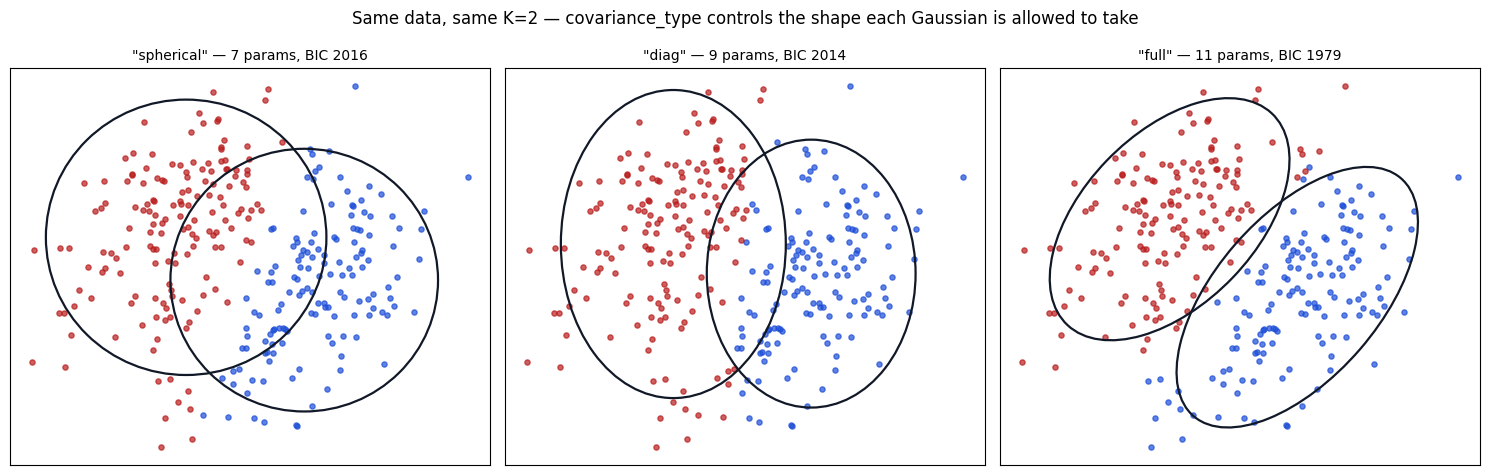

In [7]:
colors_gmm = ["#1D4ED8", "#B91C1C"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, ct in zip(axes, covariance_types):
    model = cov_fits[ct]
    labels_ct = model.predict(X_overlap)
    for j in range(2):
        ax.scatter(X_overlap[labels_ct == j, 0], X_overlap[labels_ct == j, 1], s=14, color=colors_gmm[j], alpha=0.7)
    for k in range(2):
        cov_k = model.covariances_[k]
        if ct == "spherical":
            cov_k = np.eye(2) * cov_k
        elif ct == "diag":
            cov_k = np.diag(cov_k)
        vals, vecs = np.linalg.eigh(cov_k)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
        width, height = 2 * 2 * np.sqrt(np.maximum(vals, 0))
        ax.add_patch(Ellipse(model.means_[k], width, height, angle=angle,
                              edgecolor="#111827", facecolor="none", linewidth=1.6))
    ax.set_title(f'"{ct}" — {model._n_parameters()} params, BIC {model.bic(X_overlap):.0f}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Same data, same K=2 — covariance_type controls the shape each Gaussian is allowed to take")
plt.tight_layout()
plt.show()

`"spherical"` forces two circles onto data that's actually tilted, so it has to compromise on where it draws the
boundary. `"diag"` does a bit better but still can't tilt. `"full"` is the only one that can follow the real
correlation — which is exactly why it wins on BIC despite costing more parameters.


## 6. Putting it together: GMM intuition

Back to "weekend browsers" vs. "deal hunters" overlapping from Section 1: instead of fitting one Gaussian to
everything, fit **multiple Gaussians — one per segment** — and let every customer get a likelihood score under
each Gaussian.

**The core idea, in one line:** the more likely a point is under a given Gaussian, the more it belongs to that
segment. That's the intuitive definition — Expectation-Maximization (next section) is what makes it
mathematically rigorous.


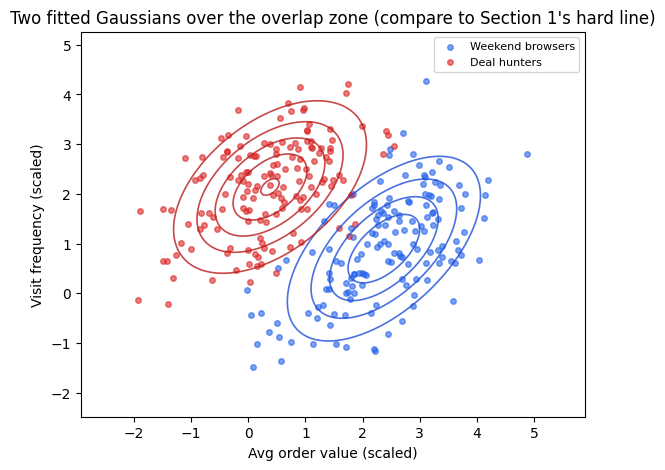

In [8]:
from sklearn.mixture import GaussianMixture

gmm_overlap = GaussianMixture(n_components=2, covariance_type="full", random_state=4).fit(X_overlap)

xg, yg = np.meshgrid(np.linspace(X_overlap[:, 0].min() - 1, X_overlap[:, 0].max() + 1, 150),
                      np.linspace(X_overlap[:, 1].min() - 1, X_overlap[:, 1].max() + 1, 150))
grid = np.dstack((xg, yg)).reshape(-1, 2)

plt.figure(figsize=(6.5, 5))
plt.scatter(*weekend_browsers.T, s=16, color="#2563EB", alpha=0.6, label="Weekend browsers")
plt.scatter(*deal_hunters.T, s=16, color="#DC2626", alpha=0.6, label="Deal hunters")
colors_gmm = ["#1D4ED8", "#B91C1C"]
for k in range(2):
    zk = multivariate_normal(gmm_overlap.means_[k], gmm_overlap.covariances_[k]).pdf(grid).reshape(xg.shape)
    plt.contour(xg, yg, zk, levels=5, colors=colors_gmm[k], linewidths=1.2, alpha=0.8)
plt.title("Two fitted Gaussians over the overlap zone (compare to Section 1's hard line)")
plt.xlabel("Avg order value (scaled)"); plt.ylabel("Visit frequency (scaled)")
plt.legend(fontsize=8)
plt.show()

Customers in the overlap zone now sit under both contour sets — GMM can score them against *both* segments
instead of drawing one hard boundary through them.

One constraint carries over from K-Means: you still have to choose `K` (the number of Gaussians / segments) up
front — typically from domain knowledge, e.g. "Marketing works with 3 tiers today." A familiar constraint, not a
new one.


## 7. The engine underneath: Expectation-Maximization (EM)

So how do you actually fit `K` Gaussians to Veloura's customers — finding the best $\mu$, $\sigma$ (covariance),
and mixing weight for each segment? **EM**, in four steps:

```{mermaid}
graph TD
    A["1. Initialization<br/>pick K random customers as initial means"] --> B["2. Expectation (E)<br/>score every customer against every Gaussian, normalize"]
    B --> C["3. Maximization (M)<br/>update each Gaussian toward the customers most confidently assigned to it"]
    C -->|not converged| B
    C -->|parameters stop changing| D["4. Converged<br/>final means, covariances, mixing weights"]

    style A fill:#BFDBFE,stroke:#374151,stroke-width:2px,color:#111827
    style B fill:#FDE68A,stroke:#374151,stroke-width:2px,color:#111827
    style C fill:#FDE68A,stroke:#374151,stroke-width:2px,color:#111827
    style D fill:#A7F3D0,stroke:#374151,stroke-width:2px,color:#111827
```

**1 · Initialization** — pick `K` random customers as the initial means, and initialize each Gaussian's variance
from the spread of the sampled data. This is a reasonable starting guess, not arbitrary — real customers are
more representative starting points than random numbers.

**2 · Expectation (E) step** — for every customer, compute their likelihood under each Gaussian, then normalize
those likelihoods into probabilities that sum to 1 across segments (the **responsibility** each Gaussian takes
for that customer):

$$
\text{responsibility}_{i,k} = \frac{P_k(x_i)}{P_1(x_i) + P_2(x_i) + \cdots + P_K(x_i)}
$$

Why normalize? Think of it like: "given it's raining, what's the probability you're in Delhi vs. New York?" You
don't just look at how likely rain is in Delhi alone — you compare it against how likely rain is in Delhi
*relative to* New York. A customer's raw likelihood under Segment A only matters relative to their likelihood
under Segments B, C, and so on.

**3 · Maximization (M) step** — update each Gaussian's $\mu$ and $\sigma$ as the *responsibility-weighted*
average of all customers. Customers who are more confidently in a segment (higher responsibility) pull that
segment's mean toward them more strongly — a weighted average, not a hard nearest-point average like K-Means's
centroid update.

**4 · Repeat** — repeat the Expectation and Maximization steps until the parameters stop changing much —
convergence.


**From scratch:** a minimal 2-Gaussian EM loop on the overlap dataset, keeping a snapshot of the fitted
Gaussians after every iteration so the convergence is visible step by step.


In [9]:
def em_gaussian_mixture(X, k, n_iters=8, seed=0):
    rng = np.random.RandomState(seed)
    n = len(X)
    means = X[rng.choice(n, k, replace=False)]
    covs = [np.cov(X.T) for _ in range(k)]
    weights = np.full(k, 1 / k)
    history = [(means.copy(), [c.copy() for c in covs])]

    for _ in range(n_iters):
        # E step: responsibility of each Gaussian for each point
        likelihoods = np.array([weights[j] * multivariate_normal(means[j], covs[j]).pdf(X) for j in range(k)])
        responsibilities = likelihoods / likelihoods.sum(axis=0, keepdims=True)

        # M step: responsibility-weighted mean, covariance, and mixing weight
        for j in range(k):
            r = responsibilities[j]
            r_sum = r.sum()
            means[j] = (r[:, None] * X).sum(axis=0) / r_sum
            diff = X - means[j]
            covs[j] = (r[:, None, None] * (diff[:, :, None] * diff[:, None, :])).sum(axis=0) / r_sum
            weights[j] = r_sum / n

        history.append((means.copy(), [c.copy() for c in covs]))

    return means, covs, weights, history

_, _, _, em_history = em_gaussian_mixture(X_overlap, k=2, n_iters=8, seed=4)

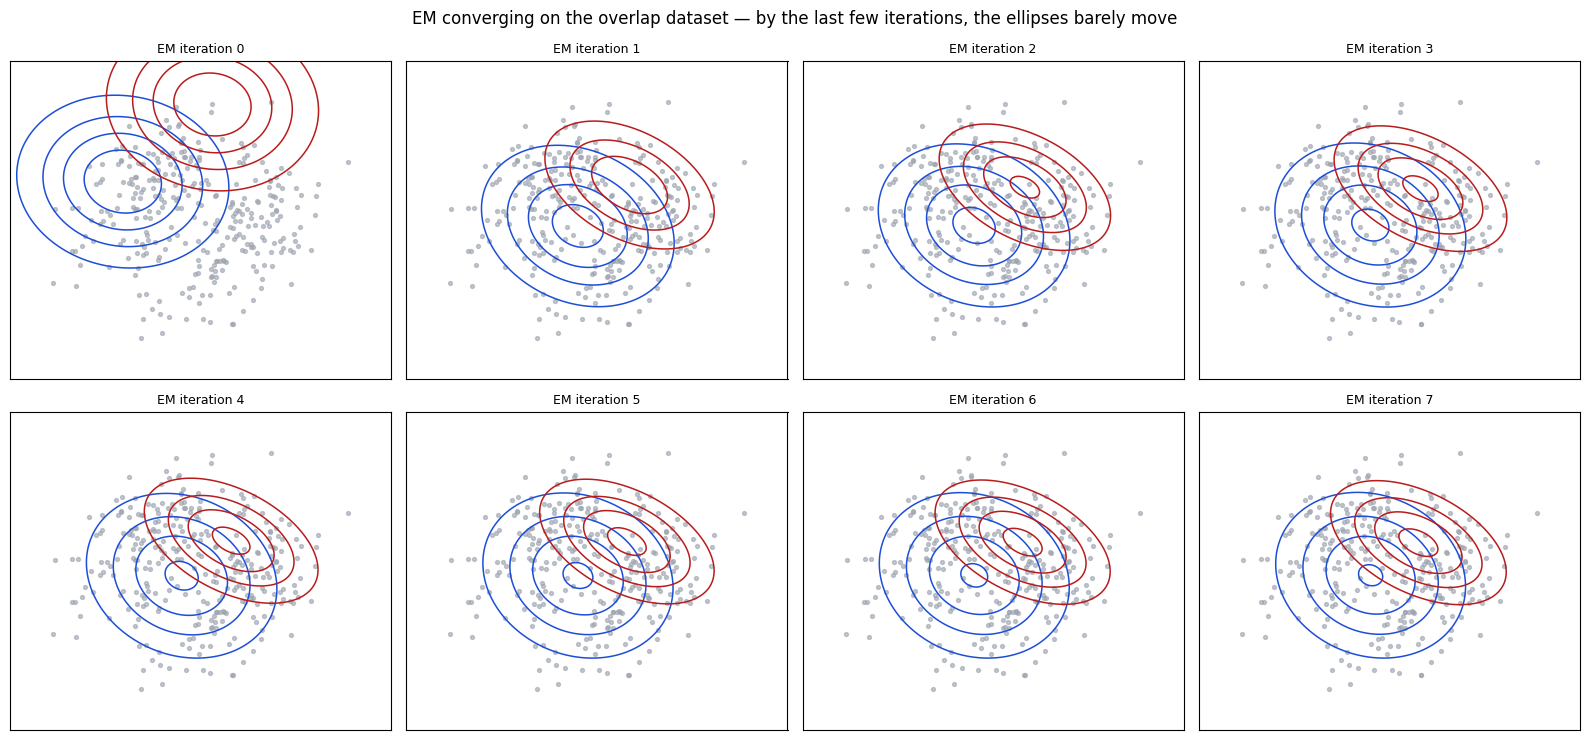

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7.5))
for step, ax in enumerate(axes.flat):
    means_step, covs_step = em_history[step]
    ax.scatter(*X_overlap.T, s=8, color="#9CA3AF", alpha=0.6)
    for k in range(2):
        zk = multivariate_normal(means_step[k], covs_step[k]).pdf(grid).reshape(xg.shape)
        ax.contour(xg, yg, zk, levels=4, colors=colors_gmm[k], linewidths=1.1)
    ax.set_title(f"EM iteration {step}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("EM converging on the overlap dataset — by the last few iterations, the ellipses barely move")
plt.tight_layout()
plt.show()

**Quick check**

> In the Maximization step of EM, how is a Gaussian's mean updated?
>
> **It's the likelihood-weighted (responsibility-weighted) average of all data points.** Not the exact center of
> the nearest points (that's K-Means), not fixed after initialization, and not chosen randomly each iteration.


## 8. Applied: segmenting Veloura customers with GMM

Time to run this for real. A synthetic dataset expands to four behavioral features (closer to the real
12-feature dataset) — average order value, visit frequency, days since last purchase, and order count — gets
standardized, and a GMM is fit with `K = 3`, matching three known underlying segments: high spenders, deal
hunters, and casual browsers.

Because GMM and K-Means are both distance-based, features are standardized first so no single feature (like
average order value, which lives on a much larger scale than visit frequency) dominates the fit.


In [11]:
from sklearn.preprocessing import StandardScaler

rng = np.random.RandomState(7)
segment_means = [
    [160, 8, 12, 10],   # high spenders: high AOV, low frequency, recent, moderate orders
    [45, 22, 4, 20],    # deal hunters: low AOV, high frequency, very recent, many orders
    [70, 5, 45, 5],     # casual browsers: mid AOV, low frequency, stale, few orders
]
segment_covs = [
    [[400, 20, -30, 15], [20, 4, -2, 3], [-30, -2, 30, -2], [15, 3, -2, 4]],
    [[150, 25, -10, 20], [25, 9, -3, 6], [-10, -3, 20, -2], [20, 6, -2, 8]],
    [[250, -5, 40, -3], [-5, 2, -5, 1], [40, -5, 80, -3], [-3, 1, -3, 2]],
]
segment_sizes = [1800, 2100, 2100]
feature_names = ["avg_order_value", "visit_frequency", "days_since_purchase", "orders"]

X_veloura = np.vstack([
    rng.multivariate_normal(m, c, s) for m, c, s in zip(segment_means, segment_covs, segment_sizes)
])
X_veloura = np.clip(X_veloura, 0, None)

scaler = StandardScaler()
X_veloura_scaled = scaler.fit_transform(X_veloura)

gmm = GaussianMixture(n_components=3, covariance_type="full", n_init=5, random_state=7)
gmm_labels = gmm.fit_predict(X_veloura_scaled)
gmm_probs = gmm.predict_proba(X_veloura_scaled)

print(f"{len(X_veloura)} synthetic Veloura customers, standardized across {X_veloura.shape[1]} features.")
for j in range(3):
    print(f"Segment {j}: {(gmm_labels == j).sum()} customers")

6000 synthetic Veloura customers, standardized across 4 features.
Segment 0: 1799 customers
Segment 1: 2100 customers
Segment 2: 2101 customers


**Pulling `predict_proba` for the two lowest-confidence customers** — the ones sitting closest to a segment
boundary:


In [12]:
from sklearn.cluster import KMeans

max_prob = gmm_probs.max(axis=1)
boundary_idx = np.argsort(max_prob)[:2]

kmeans_veloura = KMeans(n_clusters=3, n_init=10, random_state=7).fit(X_veloura_scaled)
kmeans_labels = kmeans_veloura.labels_

for i in boundary_idx:
    aov, freq, recency, orders = X_veloura[i]
    print(f"Customer #{i} — AOV ${aov:.2f} · Visit freq {freq:.2f} · Days since purchase {recency:.2f} · Orders {orders:.2f}")
    print(f"  KMeans label: Segment {kmeans_labels[i]} (hard, no alternative shown)")
    print(f"  GMM probabilities: " + ", ".join(f"Segment {j}={gmm_probs[i, j]:.2f}" for j in range(3)))

Customer #396 — AOV $85.25 · Visit freq 4.46 · Days since purchase 19.43 · Orders 7.30
  KMeans label: Segment 2 (hard, no alternative shown)
  GMM probabilities: Segment 0=0.74, Segment 1=0.00, Segment 2=0.26
Customer #1446 — AOV $98.92 · Visit freq 5.60 · Days since purchase 25.56 · Orders 6.57
  KMeans label: Segment 2 (hard, no alternative shown)
  GMM probabilities: Segment 0=0.25, Segment 1=0.00, Segment 2=0.75


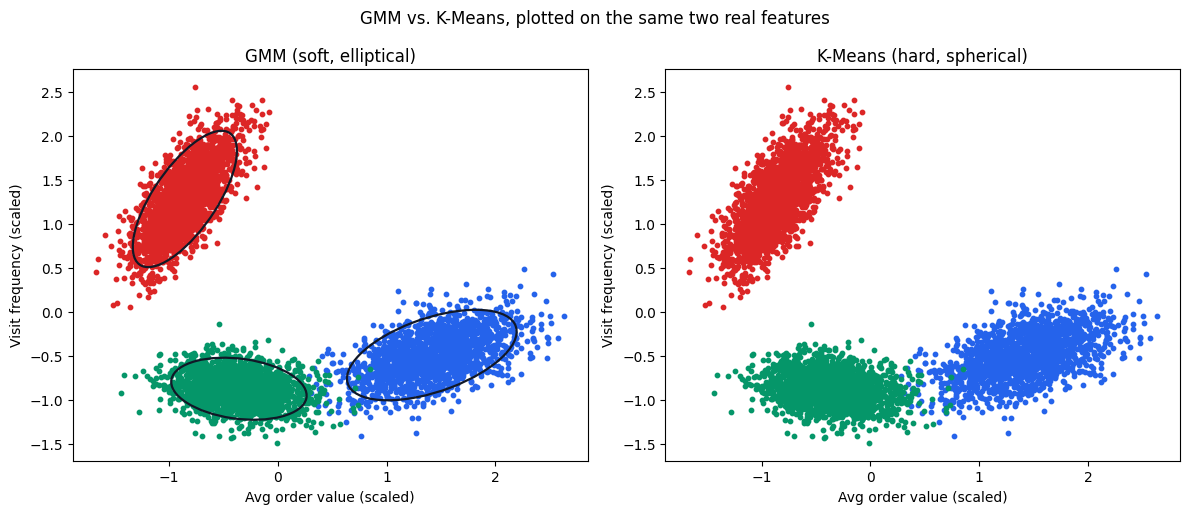

In [13]:
def draw_gmm_ellipses(ax, model, feat_x, feat_y, color="#111827"):
    for k in range(model.n_components):
        cov2d = model.covariances_[k][np.ix_([feat_x, feat_y], [feat_x, feat_y])]
        mean2d = model.means_[k][[feat_x, feat_y]]
        vals, vecs = np.linalg.eigh(cov2d)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
        width, height = 2 * 2 * np.sqrt(np.maximum(vals, 0))  # ~2 std ellipse
        ax.add_patch(Ellipse(mean2d, width, height, angle=angle,
                              edgecolor=color, facecolor="none", linewidth=1.6))

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
colors4 = ["#2563EB", "#DC2626", "#059669"]
for j in range(3):
    axes[0].scatter(X_veloura_scaled[gmm_labels == j, 0], X_veloura_scaled[gmm_labels == j, 1], s=10, color=colors4[j])
    axes[1].scatter(X_veloura_scaled[kmeans_labels == j, 0], X_veloura_scaled[kmeans_labels == j, 1], s=10, color=colors4[j])
draw_gmm_ellipses(axes[0], gmm, 0, 1)
axes[0].set_title("GMM (soft, elliptical)")
axes[1].set_title("K-Means (hard, spherical)")
for ax in axes:
    ax.set_xlabel("Avg order value (scaled)"); ax.set_ylabel("Visit frequency (scaled)")
plt.suptitle("GMM vs. K-Means, plotted on the same two real features")
plt.tight_layout()
plt.show()

GMM's ellipses visibly tilt to follow how spend and frequency move together within each segment; K-Means draws
circular boundaries regardless of that relationship. The real difference shows up at the boundaries: K-Means just
states a segment, full stop. GMM hands Marketing the full probability breakdown per customer — the blended-
campaign signal they asked for. These three synthetic segments are fairly well separated, so even the
least-confident customers above are still fairly high-probability; on real, messier Veloura data, splits like
55% / 40% / 5% are exactly where GMM earns its keep.


## 9. GMM vs. K-Means

| | K-Means | GMM |
|---|---|---|
| **Cluster shape** | Spherical (circular) | Elliptical, can be rotated |
| **Assignment** | Hard (one label) | Soft (probability per segment) |
| **Needs K upfront?** | Yes | Yes |
| **Captures feature correlation?** | No | Yes (via covariance) |
| **Boundary customers** | Forced to one side | Get a blended probability |

**K-Means is secretly a special case of GMM.** Force every Gaussian to have equal variance in every direction and
zero covariance (perfectly circular, same size), and a GMM's soft elliptical clusters collapse into K-Means's
hard circular ones.


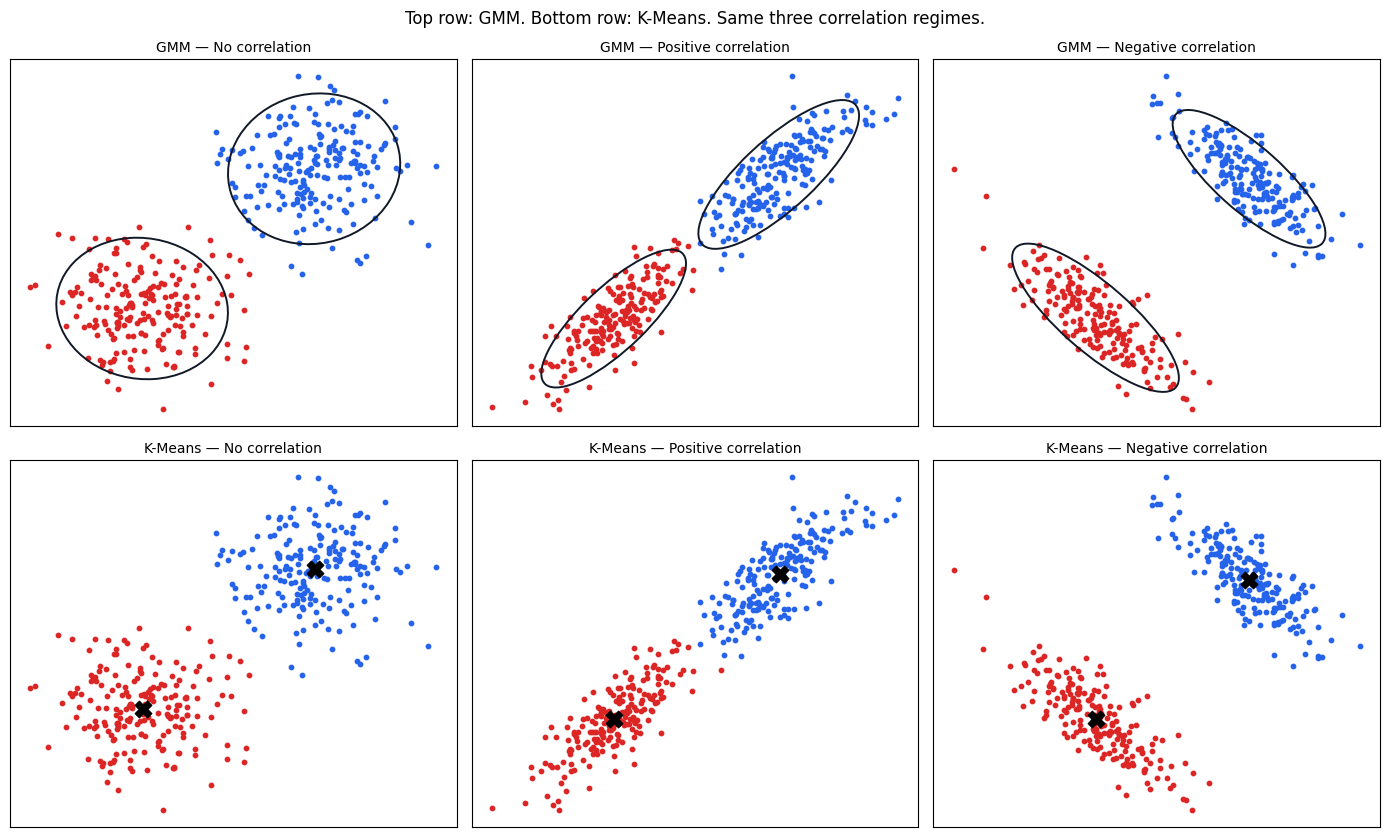

In [14]:
def make_corr_blobs_2cluster(corr, n=200, seed=0):
    rng = np.random.RandomState(seed)
    cov = np.array([[1.0, corr], [corr, 1.0]])
    c1 = rng.multivariate_normal([-2, -2], cov, n)
    c2 = rng.multivariate_normal([2, 2], cov, n)
    return np.vstack([c1, c2])

corr_cases = [("No correlation", 0.0), ("Positive correlation", 0.8), ("Negative correlation", -0.8)]
fig, axes = plt.subplots(2, 3, figsize=(14, 8.5))

for col, (title, corr) in enumerate(corr_cases):
    X_corr = make_corr_blobs_2cluster(corr, seed=col)
    gmm_corr = GaussianMixture(n_components=2, covariance_type="full", random_state=0).fit(X_corr)
    km_corr = KMeans(n_clusters=2, n_init=10, random_state=0).fit(X_corr)

    gmm_lab = gmm_corr.predict(X_corr)
    for j in range(2):
        axes[0, col].scatter(X_corr[gmm_lab == j, 0], X_corr[gmm_lab == j, 1], s=10, color=colors4[j])
    for k in range(2):
        vals, vecs = np.linalg.eigh(gmm_corr.covariances_[k])
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
        width, height = 2 * 2 * np.sqrt(np.maximum(vals, 0))
        axes[0, col].add_patch(Ellipse(gmm_corr.means_[k], width, height, angle=angle,
                                        edgecolor="#111827", facecolor="none", linewidth=1.4))
    axes[0, col].set_title(f"GMM — {title}", fontsize=10)

    km_lab = km_corr.labels_
    for j in range(2):
        axes[1, col].scatter(X_corr[km_lab == j, 0], X_corr[km_lab == j, 1], s=10, color=colors4[j])
    axes[1, col].scatter(*km_corr.cluster_centers_.T, marker="X", s=140, color="black", zorder=5)
    axes[1, col].set_title(f"K-Means — {title}", fontsize=10)

    for ax in (axes[0, col], axes[1, col]):
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("Top row: GMM. Bottom row: K-Means. Same three correlation regimes.")
plt.tight_layout()
plt.show()

- With little or no correlation, GMM learns nearly circular Gaussians, so its behavior looks similar to K-Means.
- As correlation increases, GMM rotates and stretches its Gaussian components to match the data.
- K-Means still partitions space based only on distance to centroids and cannot model tilted clusters — its
  circular boundaries stay circular no matter how correlated the underlying data actually is.


**Quick check**

> What is the core structural difference between K-Means and GMM?
>
> **K-Means does hard assignment to the nearest centroid; GMM assigns soft, probabilistic membership across all
> clusters.** Not "GMM doesn't need K" (it does), not "K-Means only works on 1D data" (it works on any
> dimensionality), and visualization isn't the distinguishing factor either.


## 10. Bonus: taking GMM live at Veloura

The segments look good, Marketing loves the blended probabilities, and someone asks the obvious next question:
*"Cool — can this run on our website, live, for every new customer the second they sign up?"*

Everything so far has happened once, on a fixed batch of customers sitting in a notebook. A real Veloura customer
might sign up at 2am, and Marketing wants their segment right then — not next Tuesday when someone reruns the
notebook. The trained GMM and the scaler that feeds it get "frozen" together into one small file — anyone holding
that file can reproduce every prediction made, without re-running any training code.


In [15]:
import joblib
import io

bundle = {"scaler": scaler, "gmm": gmm, "feature_names": feature_names}
buffer = io.BytesIO()
joblib.dump(bundle, buffer)
model_size_kb = len(buffer.getvalue()) / 1024

new_signups = np.array([
    [175, 7, 10, 8],
    [40, 25, 3, 22],
    [60, 3, 50, 3],
])

t0 = time.perf_counter()
new_scaled = scaler.transform(new_signups)
new_segments = gmm.predict(new_scaled)
new_probs = gmm.predict_proba(new_scaled)
score_time_ms = (time.perf_counter() - t0) * 1000

print(f"Packaged model size: {model_size_kb:.2f} KB")
print(f"Time to score {len(new_signups)} new signups: {score_time_ms:.3f} ms")
for i, (aov, freq, recency, orders) in enumerate(new_signups, start=1):
    print(f"Signup {i}: AOV {aov}, freq {freq}, recency {recency}, orders {orders} "
          f"-> Segment {new_segments[i-1]}, probs {new_probs[i-1].round(2)}")

Packaged model size: 2.76 KB
Time to score 3 new signups: 1.235 ms
Signup 1: AOV 175, freq 7, recency 10, orders 8 -> Segment 0, probs [1. 0. 0.]
Signup 2: AOV 40, freq 25, recency 3, orders 22 -> Segment 1, probs [0. 1. 0.]
Signup 3: AOV 60, freq 3, recency 50, orders 3 -> Segment 2, probs [0. 0. 1.]


That's the whole trick behind "fit once, reuse forever": the same frozen object built during training can sit
quietly behind a website and answer instantly, all day long.

**Models go stale quietly.** Customer behavior doesn't hold still forever. Simulating Veloura customers slowly
drifting over 12 months — spending and visiting a little more each month — shows how confident the original,
never-retrained model stays about them:


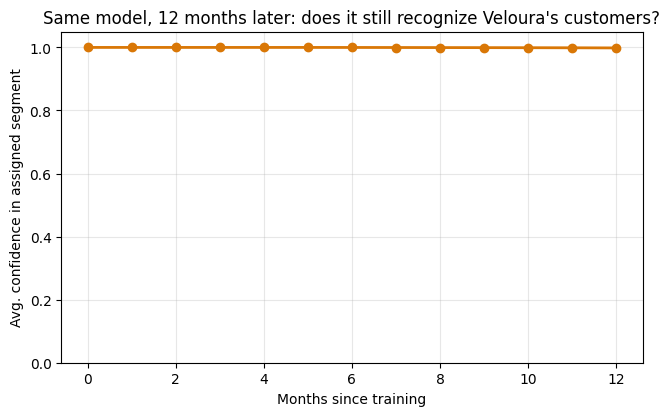

In [16]:
months = np.arange(0, 13)
avg_confidence = []
for month in months:
    drift = 1 + 0.025 * month  # customers gradually spend/visit a bit more each month
    drifted = X_veloura * np.array([drift, drift, 1.0, drift])
    drifted_scaled = scaler.transform(drifted)
    probs_drifted = gmm.predict_proba(drifted_scaled)
    avg_confidence.append(probs_drifted.max(axis=1).mean())

plt.figure(figsize=(7.5, 4.3))
plt.plot(months, avg_confidence, marker="o", color="#D97706", linewidth=2)
plt.xlabel("Months since training"); plt.ylabel("Avg. confidence in assigned segment")
plt.title("Same model, 12 months later: does it still recognize Veloura's customers?")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.show()

A model doesn't announce that it's gone stale — it just gets quietly less sure of itself. That's why teams check
back in on a live model every so often, instead of shipping it once and forgetting about it.


**Hands-on exercise (no code)**

Marketing tells you two things: they want a blended-probability view of every customer (not a single hard
label), and they've noticed their top 3 tiers from last quarter don't quite capture the "browses a lot but rarely
buys" customers anymore. Which of these is a reason to retrain the GMM, and which is just business as usual?
Reason through it before checking below.

> **Answer:** wanting blended probabilities is *not* a reason to retrain — that's GMM already doing its job via
> `predict_proba`, no retraining needed. Customer behavior drifting away from what the model learned (the
> "browses a lot but rarely buys" pattern showing up more) *is* a retraining signal — it's exactly the kind of
> quiet staleness the confidence-drift chart above is meant to catch.


## 11. Summary — revision cheat sheet

**The big idea:** replace hard, forced-into-one-cluster assignment with **soft clustering** — a probability of
belonging to each segment, produced by fitting one Gaussian distribution per cluster.

**Why Hierarchical Clustering wasn't enough:** it doesn't scale to Veloura's ~40,000 customers (pairwise distance
tracking blows up), and like K-Means, it's a *hard* clustering method — no way to express an ambiguous customer.

**The building block:** the Gaussian distribution — 1D first (mean, std, bell curve), then 2D+ (a probability
surface, with covariance controlling how the ellipse tilts to match correlated features).

**Expectation-Maximization (EM)** fits `K` Gaussians to the data in a loop:
- **E step** — score every customer against every Gaussian, normalize into responsibilities that sum to 1.
- **M step** — update each Gaussian's mean/covariance as the responsibility-weighted average of all customers.
- Repeat until convergence. See Section 7 for the full from-scratch walkthrough.

**GMM vs. K-Means:** GMM produces elliptical, rotatable clusters with soft (probabilistic) membership; K-Means
produces spherical clusters with hard membership. K-Means is what you get when a GMM is forced to have equal,
circular variance in every component — **GMM ⊃ K-Means**.

**Still need `K` upfront** — that constraint carries over from K-Means; GMM doesn't remove it, it only removes
the *hard-boundary* problem.

**Taking it live:** the fitted scaler + GMM freeze into one small object that scores new customers instantly —
but a live model goes stale quietly as customer behavior drifts, so it needs periodic re-checking, not
"fit once and forget."

**Next up:** [DBSCAN](../dbscan/notes.ipynb) — teaching the clustering algorithm to say "I don't know," fixing
both the forced-fit problem and the shape problem this notebook's GMM couldn't handle.
